<a href="https://colab.research.google.com/github/Akyzia/Analise_AirQuality/blob/main/Analise_QualidadeAr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.8 MB/s eta 0:00:00


In [ ]:
pip install folium

In [ ]:
pip install pandas

In [ ]:
pip install ee

  Preparing metadata (setup.py) ... done
  Created wheel for ee: filename=ee-0.2-py3-none-any.whl size=3655 sha256=7f782a7a46cee3ec49e8e6dea7e58155ed736a67f73e31a7b925113658169c6c
  Stored in directory: /root/.cache/pip/wheels/a0/6d/ee/1d25db5c1257f6b86266fa4c20a2439110c42e8759486066f7
Successfully built ee


In [ ]:
pip install ipywidgets

In [ ]:
pip install geopandas

In [ ]:
pip install branca

In [ ]:
!pip uninstall earthengine-api -y
!pip install earthengine-api --upgrade


Found existing installation: earthengine-api 1.5.24
Uninstalling earthengine-api-1.5.24:
  Successfully uninstalled earthengine-api-1.5.24
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 463.5/463.5 kB 10.8 MB/s eta 0:00:00


In [ ]:
pip install leaflet

In [41]:
pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 80.8 MB/s eta 0:00:00


IMPORT LIBRARIES

In [ ]:
import ee
import geemap
import geemap.foliumap as geemap
import folium
from folium.plugins import DualMap
import geopandas as gpd
import json
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
from folium.plugins import MiniMap
import branca
import webbrowser
from folium import plugins

# Correcting the import statement
import io
import platform
import time

# Authenticate your Google Earth Engine account
ee.Authenticate()

# Initialize the API
ee.Initialize(project='google-cloud-project-id')  # Replace 'google-cloud-project-id' with your Google Cloud project ID

CONNECT TO DRIVE

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**INTERACTIVE MAP FOR 2025-01-01 to 2025-07-27**

In [ ]:
#Defining the polygon
roi_ee = ee.Geometry.Polygon([
    [
      [-47.39900948813514,-23.967973372189665],
      [-46.19051339438514,-23.967973372189665],
      [-46.19051339438514,-22.970320164028813],
      [-47.39900948813514,-22.970320164028813],
      [-47.39900948813514,-23.967973372189665],
    ]
])


# Sentinel-5P NO2 dataset
no2 = ee.ImageCollection("COPERNICUS/S5P/NRTI/L3_NO2") \
    .filterDate('2025-01-01', '2025-07-27') \
    .select('NO2_column_number_density') \
    .mean()\

# Clip by the area of interest
recorte = no2.clip(roi_ee)

# Visualization parameters
viz_params = {
  'min': 0.00006006727157898048,
  'max': 0.00009087671843045335,
  'palette': ['black', 'purple', 'blue', 'cyan', 'green', 'yellow', 'red']
}

m = geemap.Map()
m.centerObject(roi_ee, zoom=8)

# Convert the geometry to Feature
roi_feat = ee.Feature(roi_ee)

# Add NO2 layer
m.addLayer(recorte, viz_params, 'Média de NO₂ entre 2025-01-01 a 2025-07-27')

# Convert the geometry to FeatureCollection
roi_fc = ee.FeatureCollection([ee.Feature(roi_ee)])


roi_styled = roi_fc.style(**{
    'color': 'orange',
    'fillColor': '00000000',
    'width': 2
})

# Add to the map
m.addLayer(roi_styled, {}, 'Área de estudo')

#LEGEND
legend_html = """
<div style="
    position: fixed;
    bottom: 40px; left: 50px; width: 60px; height: 100px;
    border:2px solid grey; z-index:9999;
    background: linear-gradient(to top, black, purple, blue, cyan, green, yellow, red);
    opacity: 0.85;
    font-size: 12px;
    font-weight: bold;
    padding: 5px 10px 1px 10px;
    color: black;
    ">
    <div style="position: relative; height: 100%; display: flex; flex-direction: column; justify-content: space-between; align-items: flex-start;">
      <span style="position: absolute; top: 0; left: 50px;">0.00006</span>
      <span style="position: absolute; bottom: 0; left: 50px;">0.00009</span>
    </div>
    <div style="position: absolute; top: -50px; left: 0px; transform: rotate(0deg); transform-origin: left top;">
        <b>Média de NO₂ (mol/m²)</b>
    </div>
</div>
"""

m.get_root().html.add_child(folium.Element(legend_html))

m

**INTERACTIVE MAP FOR 2018-01-01 to 2018-07-27**

In [ ]:
# Sentinel-5P NO2 Dataset
# Clip by the area of interest
# Visualization parameters
# Convert the geometry to a Feature
# Add NO2 layer


# Sentinel-5P NO2 Dataset
no2_2018 = ee.ImageCollection("COPERNICUS/S5P/NRTI/L3_NO2") \
    .filterDate('2018-01-01', '2018-07-27') \
    .select('NO2_column_number_density') \
    .mean()\
    
# Clip by the area of interest
recorte2 = no2_2018.clip(roi_ee)

# Visualization parameters
viz_params2 = {
  'min': 0.00008024155914010434,
  'max': 0.00015698484341786665,
  'palette': ['black', 'purple', 'blue', 'cyan', 'green', 'yellow', 'red']
}

m2 = geemap.Map()
m2.centerObject(roi_ee, zoom=8)

# Convert the geometry to a Feature
roi_feat2 = ee.Feature(roi_ee)

# Add NO2 layer
m2.addLayer(recorte2, viz_params2, 'Média de NO₂ entre 2018-01-01 a 2018-07-27')

#LEGEND
legend_html2 = """
<div style="
    position: fixed;
    bottom: 40px; left: 50px; width: 60px; height: 100px;
    border:2px solid grey; z-index:9999;
    background: linear-gradient(to top, black, purple, blue, cyan, green, yellow, red);
    opacity: 0.85;
    font-size: 12px;
    font-weight: bold;
    padding: 5px 10px 1px 10px;
    color: black;
    ">
    <div style="position: relative; height: 100%; display: flex; flex-direction: column; justify-content: space-between; align-items: flex-start;">
      <span style="position: absolute; top: 0; left: 50px;">0.00008</span>
      <span style="position: absolute; bottom: 0; left: 50px;">0.00016</span>
    </div>
    <div style="position: absolute; top: -50px; left: 0px; transform: rotate(0deg); transform-origin: left top;">
        <b>Média de NO₂ (mol/m²)</b>
    </div>
</div>
"""

m2.get_root().html.add_child(folium.Element(legend_html2))

m2

**PLOTTING 2025**

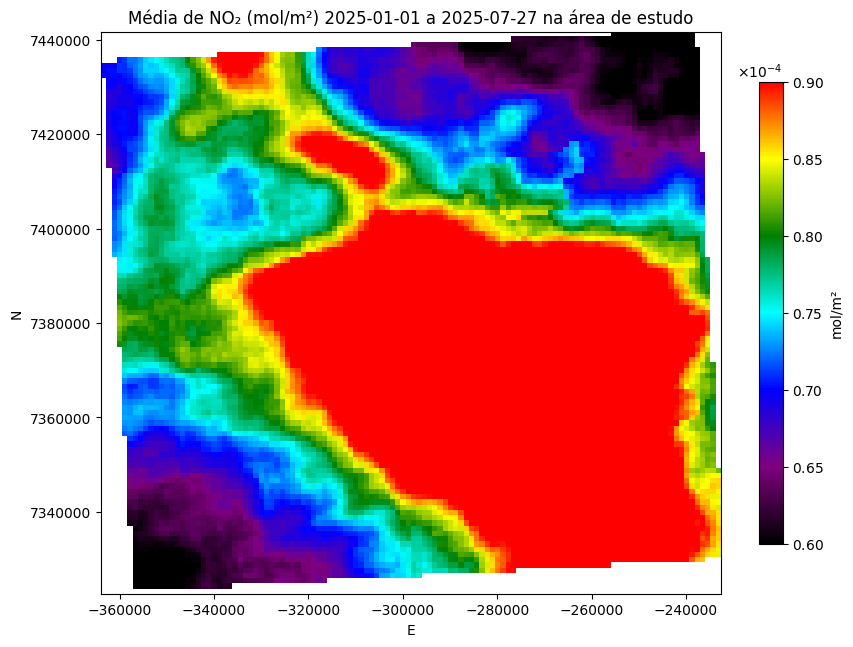

In [ ]:
import rasterio
from rasterio.plot import plotting_extent
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import ScalarFormatter
import numpy as np

# Open image 2025
with rasterio.open('/content/drive/MyDrive/ArquivosGEE/RASTER_AIR_QUALITY/NO2_MEDIA_2025.tif') as src:
    data = src.read(1)
    masked_data = np.ma.masked_equal(data, src.nodata)
    extent = plotting_extent(src)

# Color palette
colors = ['black', 'purple', 'blue', 'cyan', 'green', 'yellow', 'red']
cmap = LinearSegmentedColormap.from_list('gee_palette', colors, N=256)

# Visualization range (adjusted for this raster)
viz_params = {'min': 6e-5, 'max': 9e-5}

# Plotting
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(masked_data, cmap=cmap,
               vmin=viz_params['min'], vmax=viz_params['max'], extent=extent)

# Colorbar with scientific notation
cbar = plt.colorbar(im, ax=ax, shrink=0.6, label='mol/m²')
cbar.formatter = ScalarFormatter(useMathText=True)
cbar.formatter.set_scientific(True)
cbar.formatter.set_powerlimits((-4, -4)) # force e^-4 notation
cbar.update_ticks()

# Title and axes
#ax.set_title('Média de NO₂ (mol/m²) 2025-01-01 a 2025-07-27 na área de estudo')
ax.set_title('Average NO₂ (mol/m²) 2025-01-01 to 2025-07-27 in the study area')
ax.set_xlabel('E')
ax.set_ylabel('N')
ax.ticklabel_format(style='plain')
plt.show()


**PLOTTING 2018**

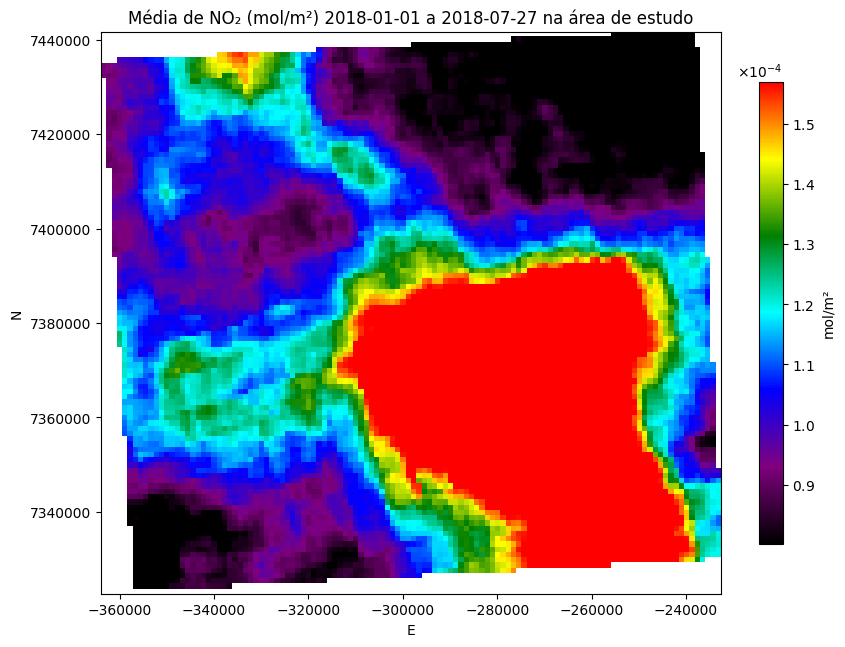

In [ ]:

# Open imagem 2018
with rasterio.open('/content/drive/MyDrive/ArquivosGEE/RASTER_AIR_QUALITY/NO2_MEDIA_2018.tif') as src:
    data = src.read(1)
    masked_data = np.ma.masked_equal(data, src.nodata)
    extent = plotting_extent(src)

# Color palette
colors = ['black', 'purple', 'blue', 'cyan', 'green', 'yellow', 'red']
cmap = LinearSegmentedColormap.from_list('gee_palette', colors, N=256)

# Actual display parameters from 2018
viz_params = {
    'min': 0.00008024155914010434,  # or rounded: 8.02e-5
    'max': 0.00015698484341786665   # or rounded: 1.57e-4
}

# Plotting
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(
    masked_data,
    cmap=cmap,
    vmin=viz_params['min'],
    vmax=viz_params['max'],
    extent=extent
)

# Color bar with scientific notation
cbar = plt.colorbar(im, ax=ax, shrink=0.6, label='mol/m²')
cbar.formatter = ScalarFormatter(useMathText=True)
cbar.formatter.set_scientific(True)
cbar.formatter.set_powerlimits((-4, -4))  # Force notation like 10⁻⁴
cbar.update_ticks()

# Title and axes
#ax.set_title('Média de NO₂ (mol/m²) 2018-01-01 a 2018-07-27 na área de estudo')
ax.set_title('Average NO₂ (mol/m²) from 2018-01-01 to 2018-07-27 in the study area')
ax.set_xlabel('E')
ax.set_ylabel('N')
ax.ticklabel_format(style='plain')
plt.show()

In [ ]:
#here I save the map as html, choosing a name
m.save("/content/drive/MyDrive/ArquivosGEE/RASTER_AIR_QUALITY/HTML/NO2_MEDIA_2025.html")
m2.save("/content/drive/MyDrive/ArquivosGEE/RASTER_AIR_QUALITY/HTML/NO2_MEDIA_2018.html")
#Opening the map with markers in the default browser
#webbrowser.open('MNO2_MEDIA_2018.html')
